<a href="https://colab.research.google.com/github/chenyujiedev/Advanced-Algorithm-Design-and-Analysis-50070-/blob/main/langchain_annotated_50250283_%E1%84%8C%E1%85%B5%E1%86%AB%E1%84%8B%E1%85%AE%E1%84%80%E1%85%A5%E1%86%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# langchain-google-genai를 설치하세요. Gemini를 사용하려면 필수이며, 이 모듈을 임포트하지 않으면 바로 오류가 발생합니다.
!pip install -q -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.7 MB/s eta 0:00:00


In [2]:
# langchain 본체를 설치합니다. -U 옵션을 사용하면 최신 버전을 보장할 수 있으며, 버전이 맞지 않으면 온갖 이상한 오류가 발생합니다.
!pip install -q -U langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.0/133.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 24.1 MB/s eta 0:00:00


In [3]:
# langgraph 설치, 나중에 직접 작성할 에이전트 그래프에 필요할 예정
!pip install -q -U langgraph

In [4]:
# Gemini API 키를 환경 변수에 추가하기
import os
os.environ["GEMINI_API_KEY"] = "숨기기 key"

In [5]:
# Gemini 채팅 모델 래핑 도입
from langchain_google_genai import ChatGoogleGenerativeAI

In [6]:
# 모델 초기화: gemini-2.0-flash를 사용하면 속도가 빠르고 무료 할당량도 넉넉합니다
my_model = ChatGoogleGenerativeAI(
    model = "gemini-3-flash-preview"
)

In [7]:
# 잠깐 langgraph가 무엇인지 물어보고, 모델이 제대로 연결되었는지 테스트해 볼게요
response = my_model.invoke("What is the langgraph?")

In [8]:
# 답장 내용 인쇄
print(response.text)

**LangGraph** is a library built on top of LangChain designed for building **stateful, multi-actor applications** with Large Language Models (LLMs).

While standard LangChain is great for creating "chains" of actions (sequences that go from A to B to C), LangGraph is designed to handle **cycles** (loops). This makes it the go-to tool for building complex **AI Agents**.

---

### Why do we need LangGraph?

To understand LangGraph, you have to understand the limitation it solves:

1.  **Chains are Linear (DAGs):** Most LLM frameworks use Directed Acyclic Graphs (DAGs). This means the process flows in one direction.
2.  **Agents need Loops:** Real-world agents don't just follow a straight line. They might:
    *   Search for information.
    *   Realize the information is incomplete.
    *   **Loop back** and search again.
    *   Ask a human for clarification.
    *   Retry a failed code execution.

LangGraph allows you to define these "loops" and maintain "state" (memory) throughout the

In [9]:
# tool 데코레이터를 도입하여 일반 Python 함수를 LangChain 도구로 래핑합니다
from langchain.tools import tool

In [10]:
# 곱셈 도구를 정의할 때, docstring이 매우 중요합니다. 모델은 이를 통해 언제 이 도구를 호출해야 할지 판단합니다.
@tool
def Multiply(a:int, b:int) -> int:
    """
    a 和 b 的 乘积
    args:
    a:第一个输入值
    b:第二个输入值
    """
    return a * b

In [11]:
# 도구를 목록에 추가하여 나중에 일괄적으로 연결할 수 있도록 합니다
my_tools = [Multiply]

In [12]:
# 도구를 모델에 바인딩하면, 모델이 어떤 도구를 사용할 수 있는지 알 수 있습니다
my_model_with_tools = my_model.bind_tools(my_tools)

In [13]:
# 수학 문제를 하나 내보겠습니다. 모델이 스스로 곱셈 도구를 조정할지 확인해 봅시다.
result = my_model_with_tools.invoke("10*12等于多少?")

In [14]:
# 인쇄 결과
print(result)

content=[] additional_kwargs={'function_call': {'name': 'Multiply', 'arguments': '{"b": 12, "a": 10}'}, '__gemini_function_call_thought_signatures__': {'5un8vxzk': 'EqwBCqkBAQw51sc62ZUT4iv5CFuVQpCtlJ0yN/cVAdJc1Ta2gY68mpYlJDDCJlD7FDXtV9F3o+ZGsW0m6Jv5u+02UTnfa6RnWECZNltSqu6Nhbpst1NKx2+ARbxXNtJjiWS0E9sfa3GsAItUlgOvm2KRznG4a6KCFO1+AjaBuFaVF3SWddYjIPuaXEg/GYtBN8pnKAskte2cmIFN0UlhPDPWpvSxoe1fj+ZSdTwIsQ=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019ee553-8d25-7513-8db9-6d79f699dcc2-0' tool_calls=[{'name': 'Multiply', 'args': {'b': 12, 'a': 10}, 'id': '5un8vxzk', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 78, 'output_tokens': 50, 'total_tokens': 128, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 32}}


In [15]:
# 여기부터는 선생님이 뒤에서 이어서 설명한 LangGraph 부분입니다.
# 앞에서는 LangChain으로 모델과 tool을 연결했고, 이제는 graph 구조로 실행 흐름을 만들어 봅니다.
# 这里开始是后续 LangGraph 内容：把前面的模型和工具放进图结构里面运行。
from langchain.messages import AnyMessage, HumanMessage, ToolMessage
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END


In [16]:
# 상태 구조 정의
# messages에는 지금까지의 대화 기록이 계속 추가됩니다.
# llm_call은 LLM을 몇 번 호출했는지 확인하기 위해 넣었습니다.
# State 用来保存对话消息和模型调用次数。
class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    llm_call: int


In [17]:
# LLM 호출 노드 정의
# 현재 messages를 모델에게 보내고, 모델의 답변을 다시 messages에 추가합니다.
# 如果模型觉得需要计算，就会在返回结果里面生成 tool_calls。
def llm_call(state: MessageState):
    result = my_model_with_tools.invoke(state["messages"])

    return {
        "messages": [result],
        "llm_call": state.get("llm_call", 0) + 1
    }


In [18]:
# 도구 목록을 딕셔너리로 변환합니다.
# 이렇게 해두면 모델이 요청한 tool 이름으로 바로 함수를 찾을 수 있습니다.
# 把工具列表变成字典，后面可以通过名字快速找到对应工具。
tools_by_name = {tool.name: tool for tool in my_tools}
tools_by_name


{'Multiply': StructuredTool(name='Multiply', description='a 和 b 的 乘积\nargs:\na:第一个输入值\nb:第二个输入值', args_schema=<class 'langchain_core.utils.pydantic.Multiply'>, func=<function Multiply at 0x78af37df6020>)}

In [19]:
# Tool 실행 노드 정의
# 모델 답변 안에 들어있는 tool_calls를 읽고, 실제 Python 함수를 실행합니다.
# 执行工具节点：真正去调用 Multiply 这个 Python 函数。
def tool_node(state: MessageState):
    result = []

    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        tool_result = tool.invoke(tool_call["args"])

        result.append(
            ToolMessage(
                content=str(tool_result),
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": result}


In [21]:
# 조건 분기 함수 정의
# LLM 답변에 tool_calls가 있으면 tool_node로 보내고, 없으면 그래프를 종료합니다.
# 判断下一步：如果模型要求调用工具，就去工具节点；否则结束。
def where_go1(state: MessageState):
    msg = state["messages"][-1]

    if getattr(msg, "tool_calls", None):
        return "tool_node"
    return END


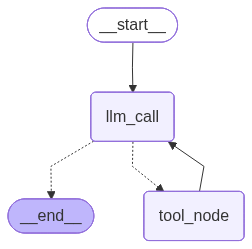

In [22]:
# LangGraph 그래프 생성
# 여기서 노드와 간선을 연결해서 Agent의 실행 순서를 만듭니다.
# 创建 LangGraph，把 llm_call 和 tool_node 连接成一个循环流程。
mygraph = StateGraph(MessageState)

# 노드 등록
mygraph.add_node("llm_call", llm_call)
mygraph.add_node("tool_node", tool_node)

# 시작점 설정
mygraph.add_edge(START, "llm_call")

# LLM 호출 후 tool 사용 여부에 따라 분기
mygraph.add_conditional_edges(
    "llm_call",
    where_go1,
    {"tool_node": "tool_node", END: END}
)

# tool 실행 후 다시 LLM으로 돌아가서 최종 답변을 만들게 합니다.
mygraph.add_edge("tool_node", "llm_call")

# 그래프 컴파일
my_agent = mygraph.compile()
my_agent


In [23]:
# 테스트 1: 곱셈 도구가 실제로 호출되는지 확인합니다.
# 测试：模型应该先调用 Multiply 工具，然后再回答最终结果。
message = [HumanMessage(content="3乘以4的结果是多少?")]

result = my_agent.invoke({
    "messages": message,
    "llm_call": 0
})

result


{'messages': [HumanMessage(content='3乘以4的结果是多少?', additional_kwargs={}, response_metadata={}, id='ab090f26-a697-4acd-a5ad-78522acf5919'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'Multiply', 'arguments': '{"a": 3, "b": 4}'}, '__gemini_function_call_thought_signatures__': {'dn4j840q': 'Eu8BCuwBAQw51seAPFgdjwxCmJEZKgGyyoopPFWcc1SiTljPaLPR58mLRAYGrEIo8klrG2eDWzOEUJ1WhgMGaKEG9ArtIGlPM/7AA0y0P4oKv3/TZtfWPUU6t3Fbot0GjPeL4/QjuxMh/M469DDXbfEO/rQGK4kXP7bGGEuhCJ3vVXXzrcjLIV8x7E6Ii1dUXoT66z7ZWi8EoYWSbTsIkxXu0YcwH7ci8H0rx3Vj53VFWnvZQi4Niykd58ET24Scybox6J46MiS97WPNA8T4+rCgfc6GOo0bCI78eYjC7OZGCfPkJb4jz8wJtN5AyDFACfg='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ee553-d07f-7c13-94fb-b5faf2b8d8d1-0', tool_calls=[{'name': 'Multiply', 'args': {'a': 3, 'b': 4}, 'id': 'dn4j840q', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'out

In [24]:
# 최종 답변만 확인합니다.
# 最后只看模型给出的最终回答。
result["messages"][-1].content


[{'type': 'text', 'text': '3乘以4的结果是12。'}]

In [25]:
# 테스트 2: 다른 곱셈 문제도 넣어 봅니다.
# 再换一个数字，确认这个 graph agent 不是只会固定答案。
message2 = [HumanMessage(content="10乘以12等于多少?")]

result2 = my_agent.invoke({
    "messages": message2,
    "llm_call": 0
})

result2["messages"][-1].content


[{'type': 'text', 'text': '10乘以12等于120。'}]